# River Flow Forecasting with Data Assimilation (DA): Latent Embedding Data Assimilation Visualizations & Sweep Evaluation

This notebook evaluates **Data Assimilation on Latent Embedding Vectors** (`embedded_dynamics`, `embedded_statics`, or `both`) in `MeanEmbeddingForecastLSTM`.

### Standardized 6-Stage Evaluation Protocol:
1. **Data Ingestion & Benchmark Initialization**: Ingest experiment-specific parquets (strictly isolated), detect horizons ($t+0 \dots t+7$), and extract Caravans V2 physical attributes.
2. **Top-N Configuration Benchmark Matrix**: Operational leaderboard with bold champions per leadtime and blue/red delta shading.
3. **Hyperparameter Influence & Main Effects Grid**: Non-parametric rank contribution (%) and marginal response curves annotated with catchment win rates (%).
4. **Cumulative Distribution Functions (CDFs) & Memory Decay**: Dual-panel CDF suite (Panel A: Fixed Lead 1 Day comparing all sweep configurations; Panel B: Multi-horizon progression comparing key reference models) + persistence decay.
5. **Basin Physical Characteristics Efficacy**: Unified 2x3 horizontal diverging effect-size bar grid (numbers cleanly positioned above whiskers) and master characteristics table.
6. **Linked Interactive Dashboard**: Dynamic Catchment Info Card, interactive Bokeh map with country boundaries and TapTool point-clicking, and continuous hydrographs with KGE & NSE in the legend.


In [71]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

# Add repository root and tutorial utils to sys.path
cwd = Path(os.getcwd()).resolve()
repo_root = next(
    (p for p in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent, Path('/usr/local/google/home/kruparell/da-paper')] if (p / 'tutorial' / 'utils').is_dir()),
    cwd
)
tut_utils = repo_root / 'tutorial' / 'utils'
if str(tut_utils) not in sys.path:
    sys.path.insert(0, str(tut_utils))

from da_eval import DAAnalysisSession
print("DA Evaluation environment loaded successfully.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
DA Evaluation environment loaded successfully.


## Stage 1: Data Ingestion & Benchmark Initialization

In this section, we initialize the evaluation session. The engine automatically:
1. Scopes data loading strictly to this experiment's directory (preventing cross-contamination).
2. **Optional In-Distribution / Overlap Filtering**: Supports filtering evaluation catchments to just the overlapping training/pretrained basins (`filter_basins=...`), filtering out unseen out-of-distribution global catchments.
3. Detects available forecast horizons (including dynamic **$t+0$ nowcast** detection).
4. Synthesizes the **Per-Basin Best DA** oracle upper bound.
5. Extracts physical morphology, slope, elevation, snow fraction, and aridity from `Caravans_V2/attributes.zarr`.

In [72]:
# Curated Experiment Selection Registry
EXPERIMENTS = {
    # 00000. Stage 53b: 4,287-Basin 6-Year (2017-01-01 .. 2023-09-30) 112-Config Decade-LR S / S+H / S+H+F Suite [XID 294151399]
    #        filtered_basins_nse_gt_0.5.txt (all 4,287 catchments), CMAL mixture_mean, NSE loss,
    #        bg=0.5, tol=0.05, epochs=50, 4 shards/config (112 configs x 4 shards = 448 V100 Borg jobs).
    #        - S (Static-only, 16 cfgs):       w in {7, 14, 30, 90} x lr_stat in {1e-4, 1e-3, 1e-2, 0.1}
    #        - S+H (Hindcast+Static, 48 cfgs): w in {7, 14, 30, 90} x lr_dyn in {1e-4, 1e-3, 1e-2, 0.1} x r in {0.1, 0.3, 1.0}
    #        - S+H+F (Triple, 48 cfgs):        w in {7, 14, 30, 90} x lr_dyn in {1e-4, 1e-3, 1e-2, 0.1} x r in {0.1, 0.3, 1.0}
    #        Partially staged 2026-09-29 while the XID was still running: only configs with all 4 shards finished
    #        were copied (105/112); re-run scratch/stage_st53.sh to pull the rest. PP rows built offline (da_eval.ar1_metrics).
    "294151399": {
        "name": "da_st53_4287b_6yr_s_sh_shf_112cfg_20260928",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st53_4287b_6yr_s_sh_shf_112cfg_20260928",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st53_4287b_6yr_s_sh_shf_112cfg_20260928",
    },
    # 0000. Stage 53: 4,287-Basin 6-Year (2017-01-01 .. 2023-09-30) 84-Config S / S+H / S+H+F Factorial Suite [XID 294056488]
    #       filtered_basins_nse_gt_0.5.txt (all 4,287 catchments), CMAL mixture_mean, NSE loss,
    #       bg=0.5, tol=0.05, epochs=50, 4 shards/config (85 configs x 4 shards = 340 V100 Borg jobs).
    #       - S (Static-only, 12 cfgs):      w in {7, 14, 30, 90} x lr in {0.001, 0.005, 0.1}
    #       - S+H (Hindcast+Static, 36 cfgs): w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #       - S+H+F (Triple, 36 cfgs):       w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #       PP benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "294056488": {
        "name": "da_st53_4287b_6yr_s_sh_shf_84cfg_20260928",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st53_4287b_6yr_s_sh_shf_84cfg_20260928",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st53_4287b_6yr_s_sh_shf_84cfg_20260928",
    },
    # 000. Stage 52: 1,000-Basin 1-Year (2017) 84-Config S / S+H / S+H+F Factorial Suite [XID 293997545]
    #      stratified_1000_screen.txt basins (n=672 finite across all 7 leads), CMAL mixture_mean, NSE loss,
    #      bg=0.5, tol=0.05, epochs=50, 1 shard/config (85 V100 jobs = 1 baseline + 84 DA configs).
    #      - S (Static-only, 12 cfgs):      w in {7, 14, 30, 90} x lr in {0.001, 0.005, 0.1}
    #      - S+H (Hindcast+Static, 36 cfgs): w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #      - S+H+F (Triple, 36 cfgs):       w in {7, 14, 30, 90} x lr_dyn in {0.001, 0.005, 0.1} x r in {0.1, 0.3, 1.0}
    #      PP benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "293997545": {
        "name": "da_st52_1000b_1yr_s_sh_shf_84cfg_20260928",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st52_1000b_1yr_s_sh_shf_84cfg_20260928",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st52_1000b_1yr_s_sh_shf_84cfg_20260928",
    },
    # 00. Stage 50: 4,287-Basin 6-Year (2017-01-01 .. 2023-09-30) Winners Benchmark [XID 293022110]
    #     11 global DA winners (4 Hindcast+Static, 2 Dual, 2 Triple, 2 Hindcast-Only, 1 Static-Only)
    #     + E_baseline_0da across all 4,287 filtered catchments (filtered_basins_nse_gt_0.5.txt),
    #     CMAL mixture_mean point estimates, 12 configs x 8 shards = 96 V100 Borg jobs.
    #     PP benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "293022110": {
        "name": "da_st50_4287b_6yr_winners_20260924",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st50_4287b_6yr_winners_20260924",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st50_4287b_6yr_winners_20260924",
    },
    # 01. Stage 51: 500-Basin 2-Year (2017-2018) 72-Config Hindcast(+Static) LR-Ratio / Tol / BG Sweep [XID 293040723]
    #     stratified_500_screen.txt basins, CMAL mixture_mean, NSE loss, 1 shard/config (73 V100 jobs).
    #     Config IDs: S51<group>_w<w>_lrd<lr_dyn>_r<lr_stat/lr_dyn>_bg<bg>_tol<tol>_ep<epochs>
    #     (r0 = hindcast-only; r>0 = hindcast + static with lr_stat = r * lr_dyn).
    #     - S51A (29): ratio sweep r in {0, 0.1, 0.3, 1}, w in {7, 14, 30, 90}, lr_dyn in {0.005, 0.01}, bg 0.5
    #     - S51B (12): heavy regularization bg in {1, 2, 5} at lr_dyn 0.1, r 0.1, w in {7, 14, 30, 90}
    #     - S51C (22): early-stopping tol in {0.01, 0.05, 0.1} x epochs in {25, 50}
    #     - S51E (5):  extreme LR / bg probes at w in {30, 90};  S51F (4): w = 365 long-window probes
    #     PP benchmark rows are generated offline from the staged Baseline zarr (da_eval.ar1_metrics).
    "293040723": {
        "name": "da_st51_500b_l47_hs_ratio_tol_bg_20260925",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st51_500b_l47_hs_ratio_tol_bg_20260925",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st51_500b_l47_hs_ratio_tol_bg_20260925",
    },
    # 0. Stage 49: 4,287-Basin 2-Year (2017-2018) Full 20-Config Global Winners Benchmark [XID 292697766]
    #    Evaluates 19 global DA winners across all 5 categories (Hindcast+Static, Triple, Dual,
    #    Hindcast-Only, Static-Only) + E_baseline_0da evaluated across all 4,287 global catchments
    #    under CMAL mixture_mean point estimates (100 V100 Borg jobs).
    "292697766": {
        "name": "da_st49_4287b_winners_suite_2yr_20260924",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st49_4287b_winners_suite_2yr_20260924",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st49_4287b_winners_suite_2yr_20260924",
    },
    # 0a. Stage 48: 500-Basin 2-Year (2017-2018) 72-Config Tier 1 Coupled Hindcast+Static Sweep [XID 292693312]
    #    Evaluates 72 hindcast_static coupled DA configs (loss_w = w in {7, 14, 30, 90},
    #    lr in {0.1, 0.01, 0.001}, bg in {0.0, 0.05, 0.5}, tol in {None, 0.05}, epochs=50)
    #    + E_baseline_0da evaluated under CMAL mixture_mean point estimates.
    "292693312": {
        "name": "da_st48_500b_hs_coupled_mixture_mean_20260924",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_st48_500b_hs_coupled_mixture_mean_20260924",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st48_500b_hs_coupled_mixture_mean_20260924",
    },
    # 0b. Stage 45: 2,000-Basin 2-Year (2017-2018) 10-Config Winners Benchmark [XID 292499199]
    #    Evaluates 9 top Embedding DA winners (Hindcast + Static W2B/S45_HS and Hindcast-Only W2/S45_H
    #    across w in {14, 30, 60}, loss in {NSE, MSE}, lw in {5, 10, 60}) + E_baseline_0da across
    #    2,000 stratified basins (10 shards/cfg = 100 V100 Borg jobs).
    "292499199": {
        "name": "da_embeddings_st45_2000b_2yr_winners_20260923",
        "mode": "embedding",
        "cns_dir": "/cns/jn-d/home/floods/hydro_model/work/kruparell/large_scale_param_selection_results/da_embeddings_st45_2000b_2yr_winners_20260923",
        "local_dir": "/usr/local/google/home/kruparell/da-paper/data/eval_staging/da_embeddings_st45_2000b_2yr_winners_20260923",
    },

}

# Select active run XID:
# - '294056488': Stage 53 4,287-Basin 6-Year (2017-01 .. 2023-09) 84-Config S / S+H / S+H+F Factorial Suite (mixture_mean)
# - '293997545': Stage 52 1,000-Basin 1-Year (2017) 84-Config S / S+H / S+H+F Factorial Suite (mixture_mean)
# - '293022110': Stage 50 4,287-Basin 6-Year (2017-01 .. 2023-09) 12-Config Winners Benchmark (mixture_mean)
# - '293040723': Stage 51 500-Basin 2-Year (2017-2018) 72-Config LR-Ratio / Tol / BG Sweep (mixture_mean)
# - '292697766': Stage 49 4,287-Basin 2-Year (2017-2018) Full 20-Config Global Winners Benchmark (mixture_mean)
# - '292693312': Stage 48 500-Basin 2-Year (2017-2018) 72-Config Coupled Hindcast+Static Sweep (mixture_mean)
# - '294151399': Stage 53b 4,287-Basin 6-Year 112-Config Decade-LR S / S+H / S+H+F Suite (partially staged)
# - '292499199': Stage 45 2,000-Basin 2-Year (2017-2018) 10-Config Winners Benchmark (CSV + Zarr staged)

ACTIVE_RUN_ID = "294151399"  # previously "293022110" (Stage 50)

selected_exp = EXPERIMENTS[ACTIVE_RUN_ID]
DATA_DIR = selected_exp["local_dir"]
CNS_DIR = selected_exp["cns_dir"]
MODE = selected_exp["mode"]
ATTR_ZARR = "/usr/local/google/home/kruparell/Caravans_V2/attributes.zarr"

# Sync Toggle: Set True to pull new shards from CNS; False for ultra-fast local loading once staged.
SYNC_FROM_CNS = False

# Basin filtering: Filter strictly to overlapping pretrained/training catchments
FILTER_BASINS_PATH = "/usr/local/google/home/kruparell/da-paper/basin_lists/filtered_basins_nse_gt_0.5.txt"
FILTER_TO_OVERLAPPING = False  # Set to False to analyze all evaluated catchments

# Report how many configs are actually staged locally (auto-syncs from CNS if 0 staged locally).
from pathlib import Path as _Path
_staged_csvs = list(_Path(DATA_DIR).glob("**/test_metrics*.csv"))
_staged_zarrs = list(_Path(DATA_DIR).glob("**/test_results*.zarr"))
_staged_parquets = list(_Path(DATA_DIR).glob("*.parquet"))
print(f"Loading Experiment XID {ACTIVE_RUN_ID} ({selected_exp['name']}) [Mode: {MODE}]...")
print(f"Locally staged files: {len(_staged_csvs)} metric CSVs, {len(_staged_zarrs)} Zarr stores, {len(_staged_parquets)} parquets")

# PP benchmark rows (fixed rho + per-basin best rho) are synthesised from the staged Baseline zarr the
# first time an experiment is loaded (~20 s per 1k basins-years; skipped when the CSVs already exist).
if _staged_zarrs:
    from da_eval.ar1_metrics import build_ar1_metrics
    build_ar1_metrics(DATA_DIR)

SELECTION = dict(metric="NSE Skill Score", leads=(4,5,6,7), agg="mean", global_stat="median")

session = DAAnalysisSession(
    selection=SELECTION,
    mode=MODE,
    data_dir=DATA_DIR,
    attr_zarr_path=ATTR_ZARR,
    cns_dir=CNS_DIR if (SYNC_FROM_CNS or (not _staged_csvs and not _staged_parquets)) else None,
    filter_basins=FILTER_BASINS_PATH if FILTER_TO_OVERLAPPING else None,
    load_timeseries=False,  # Fast loading for full 4,287-basin metrics (~8s)
)

Loading Experiment XID 294151399 (da_st53_4287b_6yr_s_sh_shf_112cfg_20260928) [Mode: embedding]...
Locally staged files: 484 metric CSVs, 424 Zarr stores, 0 parquets
Initializing DA Analysis Session (Mode: EMBEDDING)...
[INFO] No parquet files found for evaluation metrics. Attempting legacy CSV ingestion from /usr/local/google/home/kruparell/da-paper/data/eval_staging/da_st53_4287b_6yr_s_sh_shf_112cfg_20260928...
[LEGACY CSV] Ingested 3,601,080 evaluation metrics across 120 configs.
Detected Horizons: 7 lead times (Leads 1..7)
Synthesizing Per-Basin Best DA benchmarks across 4,287 catchments...
[SELECTION] selected on median of mean NSE skill score over t+4–7: Global-Best DA = S52_T_w90_lrd0.001_r1.0_bg0.5_tol0.05_ep50 | Global-Best PP = AR1_postprocess_rho0.65 (ranked on 2,837 common basins)
Extracting physical morphology and climate attributes from Caravans V2 zarr...
Computing effect-size statistics across 6 physical dimensions...
Session initialized successfully.


### Reference models (set once for the whole notebook)

`SELECTION` in the cell above defines **Global-Best DA**, **Per-Basin DA**, **Global-Best PP** and **Per-Basin PP** for every later stage.

**PP** = error-correction **post-processing** of the open-loop forecast: the last observed error is carried forward with persistence ρ, i.e. $\hat q(T{+}L) = q_{base}(T{+}L) + \rho^L\,[q_{obs}(T) - q_{base}(T)]$, clipped at 0 (Global-Best PP = one ρ for all gauges; Per-Basin PP = best ρ per gauge). "AR" is reserved for the autoregressive LSTM. No plot or table chooses its own reference models, and the same Global-Best config is shown at every lead time. Plot titles and legends state the rule (e.g. *selected on median NSE skill score, t+1*).

> [!NOTE]
> Selection is **in-sample**: models are chosen on the same period they are evaluated on. Per-Basin models are therefore oracle upper bounds, and the Global-Best is optimistic by a (small) selection bias.


In [73]:
# Display units: NSE skill score shown as a percentage in every plot / table (SS_NSE x 100 = % reduction in
# squared error vs the open-loop). Presentation only - thresholds, colour limits and arguments stay fractions
# (e.g. vmin=-0.2 -> -20%, bin_thresholds "0.01, 0.05" -> 1% / 5%). Set False for raw fractions.
session.set_ss_percent(True)

# Colours / line styles of the reference models (Baseline, Global / Per-Basin DA, Global / Per-Basin PP),
# used by every plot below. "cvd_safe" = colour-blind safe (default); "legacy" = the earlier Google colours.
session.set_palette("cvd_safe")

# Ranking behind the selection (DA and PP pools, winner = bold) and each config's share of Per-Basin wins.
session.selection_summary()


Config ID,Pool,median (%),N basins,% basins best,Global-Best
S52_T_w90_lrd0.001_r1.0_bg0.5_tol0.05_ep50,DA,1.9%,2837,0.811,True
S52_T_w30_lrd0.001_r1.0_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.564,False
S52_HS_w30_lrd0.01_r0.1_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.811,False
S52_HS_w90_lrd0.001_r1.0_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.881,False
S52_T_w90_lrd0.01_r0.3_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.529,False
S52_HS_w30_lrd0.001_r1.0_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.423,False
S52_T_w14_lrd0.001_r1.0_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.670,False
S52_T_w30_lrd0.01_r0.3_bg0.5_tol0.05_ep50,DA,1.7%,2837,0.317,False
S52_T_w90_lrd0.001_r0.3_bg0.5_tol0.05_ep50,DA,1.6%,2837,0.211,False
S52_HS_w30_lrd0.01_r0.3_bg0.5_tol0.05_ep50,DA,1.6%,2837,0.388,False


## Stage 2: Headline Summary (Paper Table 1)

Open-loop baseline NSE per lead window (column headers) and the NSE skill score (% reduction in squared error vs the open-loop) 
of each reference scheme. The per-config leaderboard and optimal-basin distribution moved to `08_DA_Exploration_Tools.ipynb`.


In [74]:
# Paper summary table: Baseline open-loop NSE (first row) + NSE skill score (SS_NSE) of each reference scheme
# per lead window. Per basin: mean over the window's leads; then the median across the common basins.
# Global / Per-Basin rows follow the notebook-wide SELECTION (Stage 1). Raw numbers: session.horizon_table
session.show_horizon_summary_table(
    windows={"Short-Range (Days 1–3)": (1, 2, 3),
             "Medium-Range (Days 4–7)": (4, 5, 6, 7),
             "Full Horizon (Days 1–7)": (1, 2, 3, 4, 5, 6, 7)},
    stat="median",
    baseline_in_header=True,   # open-loop NSE under each column heading (False = separate Baseline row)
    # percent follows session.set_ss_percent (Stage 1); pass percent=True/False to override for this table
    # labels={"global_rho": "Global PP Post-Processing (SS<sub>NSE</sub>)"},   # optional row renames
)


,Short-Range (Days 1–3)NSEbase = 0.630,Medium-Range (Days 4–7)NSEbase = 0.525,Full Horizon (Days 1–7)NSEbase = 0.569
Assimilation Scheme — SSNSE (%),,,
Global Default DA,+8.5%,+1.9%,+4.4%
Global-Best PP,+11.2%,+1.0%,+5.2%
Per-Basin Best DA,+10.6%,+6.0%,+8.2%
Per-Basin PP,+8.7%,+1.0%,+4.6%


,Short-Range (Days 1–3)NSEbase = 0.630,Medium-Range (Days 4–7)NSEbase = 0.525,Full Horizon (Days 1–7)NSEbase = 0.569
Assimilation Scheme — SSNSE (%),,,
Global Default DA,+8.5%,+1.9%,+4.4%
Global-Best PP,+11.2%,+1.0%,+5.2%
Per-Basin Best DA,+10.6%,+6.0%,+8.2%
Per-Basin PP,+8.7%,+1.0%,+4.6%


## Stage 4: Hyperparameter Influence, Risk Profiles & Downside Tail Analysis

* **Interactive Risk & Distribution Suite**: Interactively stratify the entire hyperparameter space by **Learning Rate (LR)**, **Background Weight (bg)**, **Assimilation Window (w)**, or **Early Stopping Tolerance (tol)**.
* **Downside Tail Metric ($Q_{0.05}$)**: Directly identifies safe vs. risky parameter regimes by measuring the 5th percentile ($Q_{0.05}$ downside drop), severe degradation rate ($\text{SS} < -0.10$), safe configuration percentage, and upside potential ($Q_{0.75}, Q_{0.95}$).
* **Marginal Influence Plot**: Also supports running the ANOVA rank decomposition and marginal response curves.

In [ ]:
# Interactive Hyperparameter Risk Profile & Downside Tail Analysis
# Toggle between Learning Rate, BG Regularization, Window, and Tolerance
# to inspect downside degradation (Q0.05), severe degradation rates, and win rates
session.show_hyperparameter_risk_suite(default_group="Learning Rate", default_lead=1)

Output()

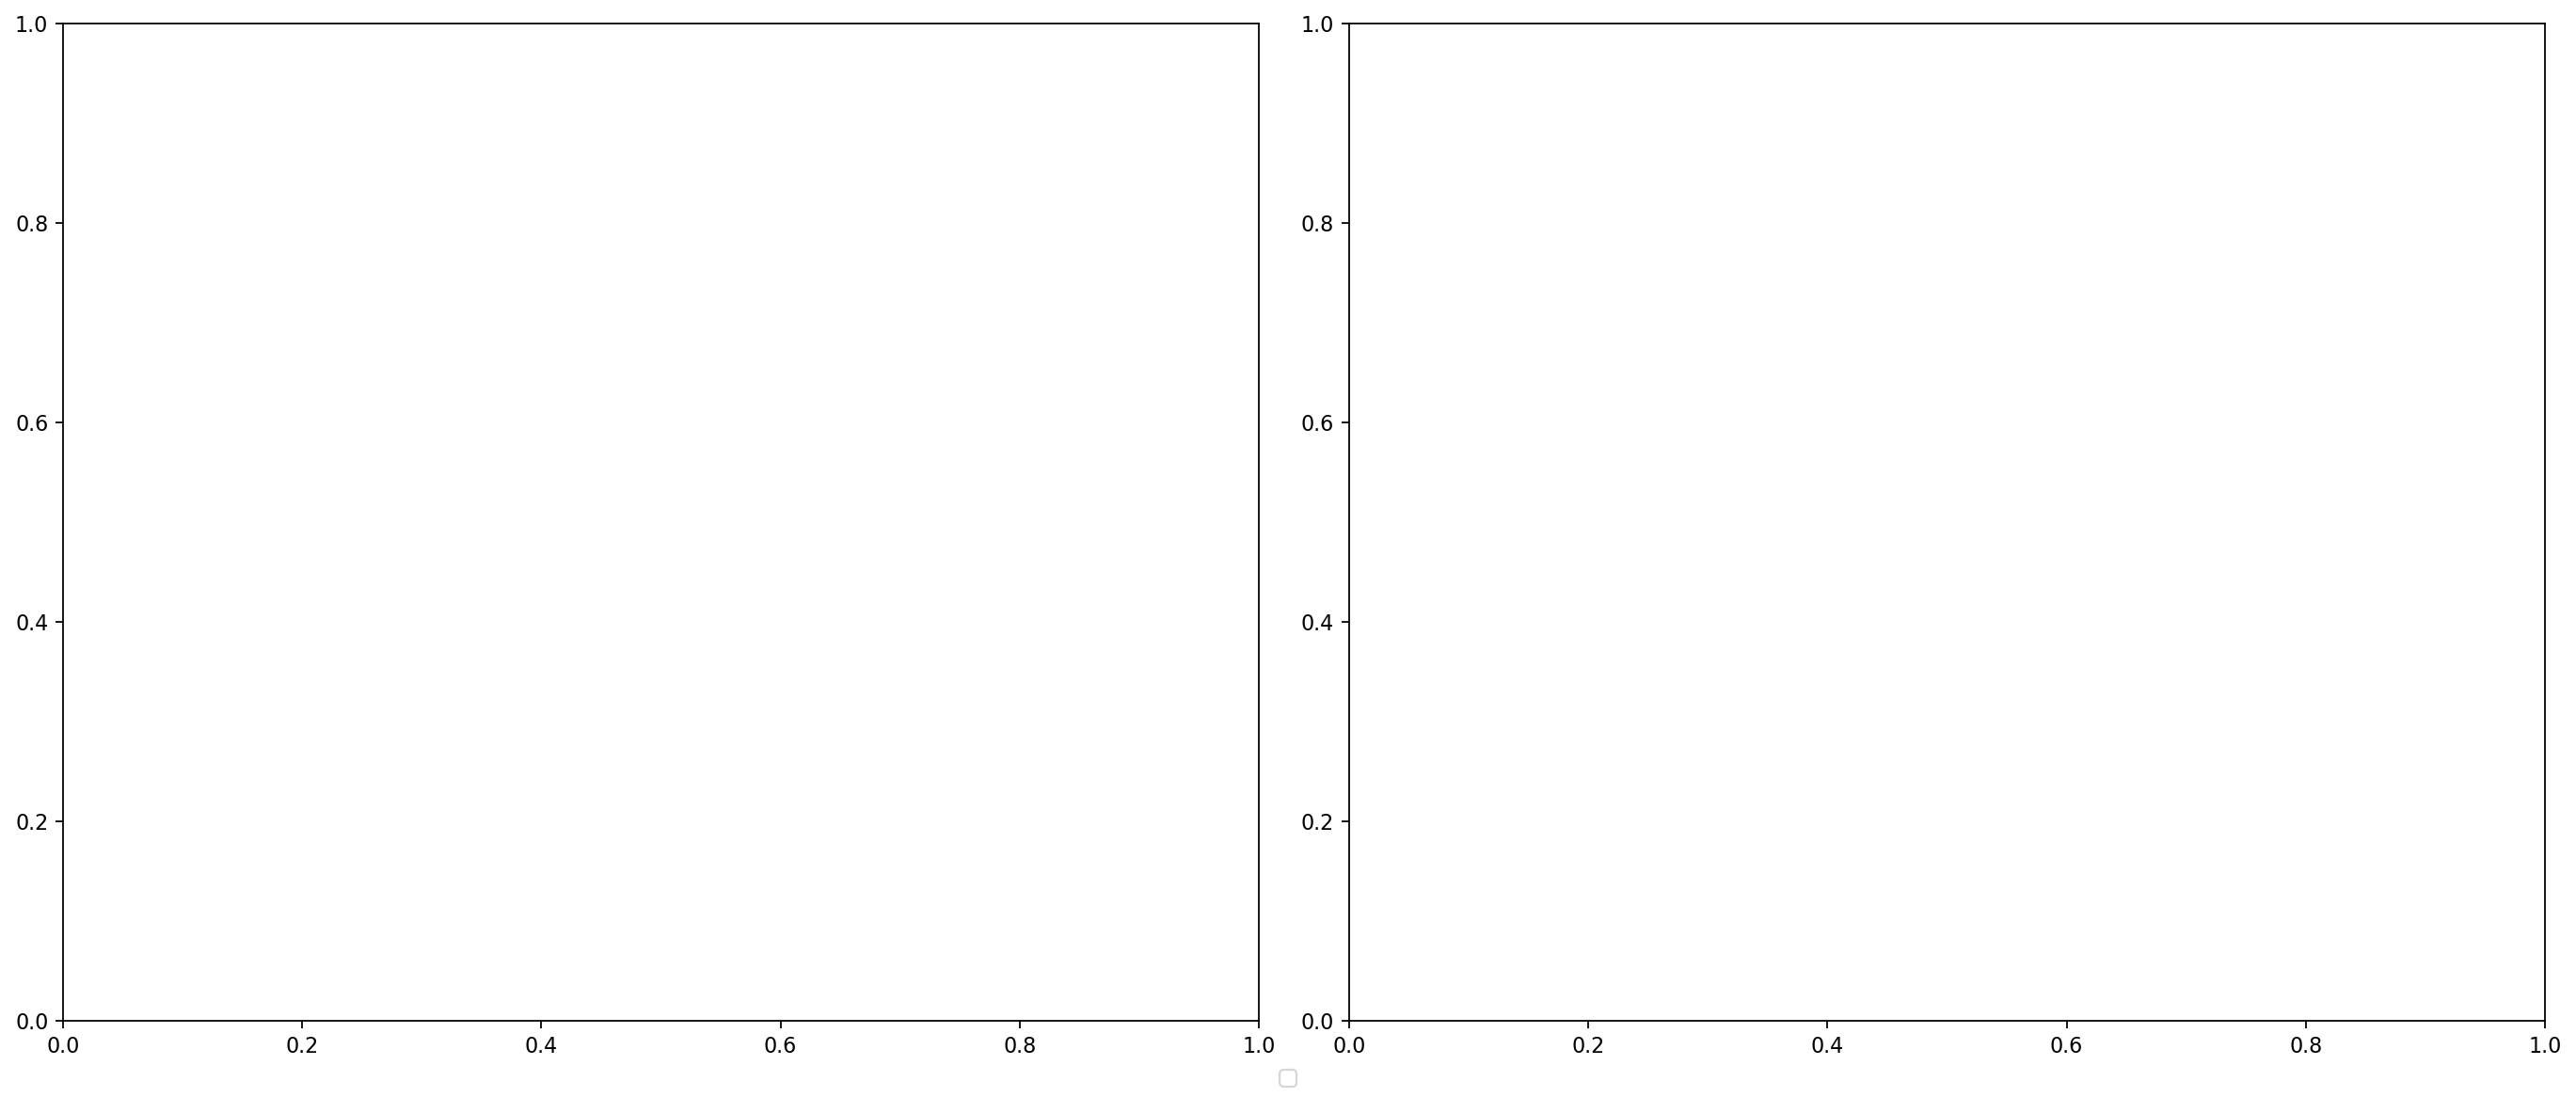

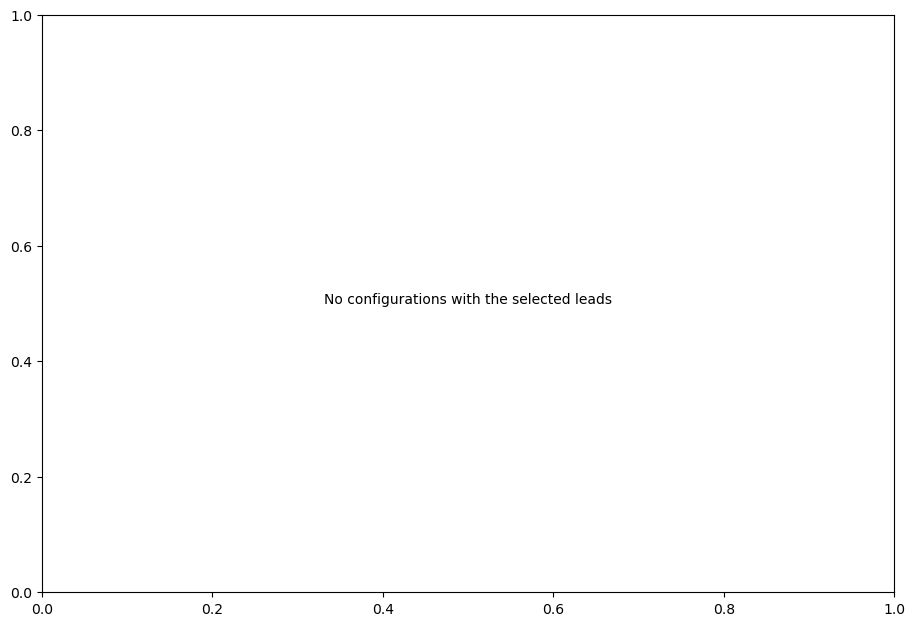

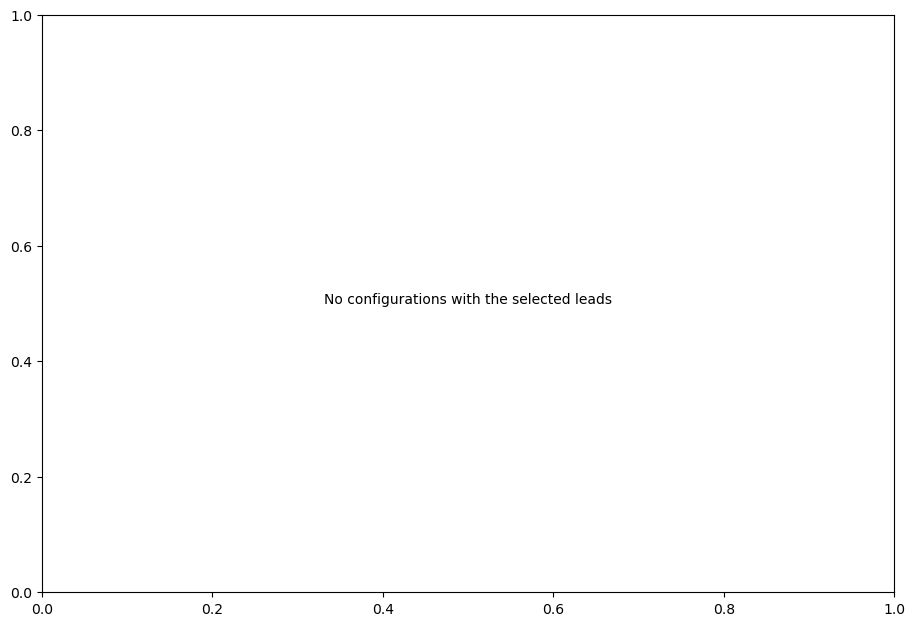

(a) Days 1–3 (N = 0)


KeyError: 'Is Sweep'

In [ ]:
# Static Paper Figure (Figure 1c): Learning Rate as a Conservativeness / Tail-Safety Dial
# Two risk-return panels on the NSE skill score (per basin, mean over the lead window):
#   (a) Days 1-3  |  (b) Days 4-7   -- one shared legend below (colour = Learning Rate, shape = LR Ratio).
# Reference models (Global-Best / Per-Basin DA) follow the notebook-wide SELECTION (Stage 1), in both panels.
# If Per-Basin DA falls outside a panel's view it is pinned to the edge with an arrow; its true coordinates
# are written in a box in that panel's emptiest corner.
import matplotlib.pyplot as plt
from da_eval import risk_return as rr

LEAD_WINDOWS = {"(a) Days 1–3": (1, 2, 3), "(b) Days 4–7": (4, 5, 6, 7)}
panels = []
for name, leads in LEAD_WINDOWS.items():
    tbl, info = session.get_risk_return_table(leads=leads, metric="skill", agg="mean")
    panels.append((tbl, info, f"{name} (N = {info['n_basins']})"))

fig_rr = rr.plot_risk_return_panels(
    panels,
    figsize=(17, 7.2),
    risk_stat="q10", return_stat="median",
    color_by="Learning Rate", marker_by="LR Ratio",   # swap marker_by="Target" for S / S+H / S+H+F shapes
    label_by=None, label_frontier=0,                  # no in-plot text
    show_refs=("baseline", "global_da"),
    inset_refs=("per_basin_da",),                     # off-scale callout instead of stretching the axes
)
fig_rr.set_dpi(160)
plt.show()

# Pareto-optimal configurations per lead window (sorted by 50th-percentile skill)
for (tbl, info, title) in panels:
    print(title)
    display(rr.style_frontier_table(rr.frontier_table(tbl, risk_stat="q10", return_stat="median"), metric="skill"))


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

day_picker = widgets.ToggleButtons(
    options=[(f"Day {d}", d) for d in range(1, 8)], value=1,
    description="Lead:", style={"button_width": "64px"},
)
out_day = widgets.Output()

def _plot_single_day(change=None):
    d = day_picker.value
    with out_day:
        clear_output(wait=True)
        tbl, info = session.get_risk_return_table(leads=(d,), metric="skill", agg="mean")
        fig = rr.plot_risk_return_panels(
            [(tbl, info, f"Day {d} (N = {info['n_basins']})")],
            figsize=(10, 7.2),
            risk_stat="q10", return_stat="median",
            color_by="Learning Rate", marker_by="LR Ratio",
            label_by=None, label_frontier=0,
            show_refs=("baseline", "global_da"),
            inset_refs=("per_basin_da",),
        )
        fig.set_dpi(160)
        plt.show()
        display(rr.style_frontier_table(
            rr.frontier_table(tbl, risk_stat="q10", return_stat="median"), metric="skill"))

day_picker.observe(_plot_single_day, names="value")
display(day_picker, out_day)
_plot_single_day()

ToggleButtons(description='Lead:', options=(('Day 1', 1), ('Day 2', 2), ('Day 3', 3), ('Day 4', 4), ('Day 5', …

Output()

## Stage 5: Cumulative Distribution Functions (CDFs) & Leadtime Memory Decay

* **Interactive Single-Cell Metric Toggle**: Switch seamlessly between **Per-Gauge $\Delta\text{NSE}$**, **NSE Skill Score ($\text{SS}_{\text{NSE}} = 1 - \frac{1 - \text{NSE}_{\text{DA}}}{1 - \text{NSE}_{\text{Base}}}$)**, **Per-Gauge $\Delta\text{KGE}$**, **Absolute $\text{NSE}$**, and **Absolute $\text{KGE}$** across forecast horizons (`t+1` to `t+7`).
* **Dual-Panel CDF Suite**:
  * **Panel A (Fixed Horizon)**: Per-gauge ECDF across all evaluated configurations vs. Open-Loop Baseline ($\Delta = 0$ / $\text{SS} = 0$), **Global Best DA**, and **Per-Basin Best DA (Oracle)** with median gain and gauge win-rate (%) annotations.
  * **Panel B (Multi-Horizon Progression)**: ECDF progression from short-range (`t+1`) to medium-range (`t+7`) forecasts.
* **Memory Persistence & Skill Decay Curve**: Tracks median performance (or median $\Delta$ / skill score gain) and `[25th, 75th]` IQR across all lead times.

In [ ]:
# Single-Cell Interactive CDF & Horizon Decay Suite
# Toggle between:
#   - "skill_nse": Per-Gauge NSE Skill Score [1 - (1 - DA NSE) / (1 - Base NSE)] (Default)
#   - "delta_nse": Per-Gauge ΔNSE (DA - Baseline)
#   - "delta_kge": Per-Gauge ΔKGE (DA - Baseline)
#   - "NSE":       Absolute NSE
#   - "KGE":       Absolute KGE
# Models row: toggle Global-Best DA / Per-Basin DA / Global-Best PP / Per-Basin PP (post-processing) and
# the grey sweep curves. `show=` sets the starting selection, e.g.
#   show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"]
# Plot row: kind="cdf" | "box" (box = IQR, whiskers = Q10–Q90); panels="b" = multi-day panel only
#   (paper figure), panels="ab" = also show panel (a) single-lead + sweep.
# (Set interactive=False to render static figures directly, e.g. session.plot_ecdfs(metric="skill_nse", interactive=False))
session.plot_ecdfs(metric="skill_nse", lead_time=1, interactive=True, show_decay=True,
                   show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"],
                   kind="cdf", panels="b")

TypeError: DAAnalysisSession.plot_ecdfs() got an unexpected keyword argument 'kind'

### Stage 5c: Harm / Benefit (Paper)

Share of gauges improved or harmed relative to the open-loop, per lead and reference model (thresholds ±1% and ±5% SS). 
Uses one common gauge set and the notebook-wide `SELECTION` (Per-Basin models are in-sample oracles). 
Skill-score CDFs and lead-time decay are in the Stage 5 ECDF suite above; absolute-NSE CDFs with Persistence and the 
violins are available (commented) in the cell below.


In [ ]:
# Paper harm/benefit figure: share of gauges improved / harmed vs the open-loop, per lead and model.
# The skill-score CDFs + lead-time decay are the Stage 5 ECDF suite above (cell "Single-Cell Interactive CDF").
PAPER_MODELS = ["Global-Best DA", "Per-Basin DA", "Global-Best PP"]
_ = session.plot_harm_benefit_bars(models=PAPER_MODELS, bin_thresholds=(0.01, 0.05))

# Other publication views (not in the paper set; uncomment if needed):
# _ = session.plot_skill_cdf_panels(leads=(1, 3, 7), metric="NSE", models=PAPER_MODELS)   # absolute NSE + Persistence
# _ = session.plot_skill_decay(metric="NSE", models=PAPER_MODELS, harm_thresholds=(0.01, 0.05))
# session.show_paper_skill_figures(main_leads=(1, 3, 7), supplement=True, metric="NSE", models=PAPER_MODELS)


StopIteration: 

## Stage 6: Basin Physical Characteristics Efficacy (6 Dimensions)

Macro-level effect-size analysis examining where Data Assimilation provides maximum benefit:
1. **Aridity Index ($P/\text{PET}$)**
2. **Baseline Performance Tier (Base NSE)**
3. **Flow Regime Seasonality**
4. **Catchment Drainage Area ($\text{km}^2$)**
5. **Snow Fraction**
6. **Terrain Slope (degrees)**

In [ ]:
# Skill score by catchment characteristic, on one common gauge set with the notebook-wide reference models.
# Toggle: Overview (one row per characteristic: most / least helped bin, gap, Kruskal-Wallis p) or one
# characteristic at a time (box plot, whiskers = Q10-Q90, + small per-bin table); lead or window; models.
# Bins with < min_n gauges are merged into their neighbour. Static: dimension="Aridity", leads=(4, 5, 6, 7).
session.plot_basin_characteristics_efficacy(
    interactive=True,
    models=["Global-Best DA", "Per-Basin DA"],   # + "Global-Best PP", "Per-Basin PP"
    min_n=20,
)


[WARNING] Evaluation records are empty. Cannot plot basin characteristics efficacy.


In [ ]:
# Gains per catchment class at a glance: rows = characteristics, columns = classes (low -> high value),
# cell = "Global-Best DA / Per-Basin DA" median NSE skill score, colour = Global-Best DA (red = harm).
# Leads follow SELECTION; e.g. leads=(1,) for one day, color_by="Per-Basin DA", vmax=0.1 to cap the colour scale.
session.plot_basin_characteristics_grid(models=["Global-Best DA", "Per-Basin DA"])


AttributeError: 'DAAnalysisSession' object has no attribute 'plot_basin_characteristics_grid'

## Stage 7: Candidate Gauge Identification & Basin Case Studies

Identify candidate gauges across physical dimensions to showcase specific hydrological behaviors in publications and presentations:
1. **Initial NSE / Baseline Quality Tiers** (Poor, Moderate, Strong)
2. **Seasonal Flow Regimes** (High-Flow Wet Season vs. Low-Flow Dry Season)
3. **Aridity Regimes** (Arid, Semi-Arid, Dry Sub-Humid, Humid)
4. **Catchment Drainage Area** (Small, Medium, Large)
5. **Average Precipitation** (Low, Moderate, High)

For any selected candidate gauge, render publication-ready **2-subplot Basin Case Study hydrographs** comparing Lead 1 ($t+1$) and Lead 7 ($t+7$) convergence across swept training epochs.

In [ ]:
# Curated Paper-Showcase Candidate Basins for Stage 48 (500 Basins, 2017-2018):
# Base NSE in [0.50, 0.76], Global Best SS >= +0.70 at Lead 1, High Peak Alignment & High KGE
PAPER_SHOWCASE_BASINS = [
    "hysets_06AD001",    # Base NSE: 0.74 -> DA: 0.96 (SS: +0.87, KGE: 0.81 -> 0.98, Basin Best DA: 0.97)
    "camelscl_4703002",  # Base NSE: 0.61 -> DA: 0.94 (SS: +0.85, KGE: 0.80 -> 0.94, Basin Best DA: 0.94)
    "hysets_06071300",   # Base NSE: 0.65 -> DA: 0.92 (SS: +0.78, KGE: 0.78 -> 0.96, Basin Best DA: 0.92)
    "hysets_02053200",   # Base NSE: 0.51 -> DA: 0.89 (SS: +0.77, KGE: 0.55 -> 0.93, Basin Best DA: 0.89)
    "hysets_02357150",   # Base NSE: 0.75 -> DA: 0.94 (SS: +0.74, KGE: 0.81 -> 0.95, Basin Best DA: 0.94)
    "hysets_02047500",   # Base NSE: 0.70 -> DA: 0.91 (SS: +0.71, KGE: 0.77 -> 0.95, Basin Best DA: 0.93)
    "camelscl_8144001",  # Base NSE: 0.51 -> DA: 0.85 (SS: +0.70, KGE: 0.75 -> 0.90, Basin Best DA: 0.88)
    "camelscl_5721001",  # Base NSE: 0.79 -> DA: 0.94 (SS: +0.69, KGE: 0.83 -> 0.96, Basin Best DA: 0.94)
]

# Consolidated Stage 7 Case Study Suite:
# Plots Observed (q_obs), Baseline Open-Loop, Global Best DA, and Basin Best DA (Oracle).
# Use the "Base NSE" range slider and "Min Global Best SS" slider to filter candidate gauges.
# Figure style (also toggles in the last widget row):
#   paper=True        big text, short model names, no config IDs / footnote
#   legend="top"      shared model legend above the hydrographs ("bottom" = below, "inside" = per panel)
#   show_metrics      NSE / SS / KGE in the legend (off by default with paper=True)
#   precip_legend     show / hide the precipitation key (hyetograph is still drawn)
#   font_scale        font multiplier (paper default 2.0; the "Font ×" slider overrides it)
#
# Current candidate basins for the paper (type the ID into "Search:"):
#   hysets_09035900
#   camels_05057200
#   hysets_06719505
#   camels_09107000   <- so far best

session.show_case_study_suite(
    n_per_regime=1,
    year=2017,
    category="all",
    min_delta=0.20,
    sort_by="skill_desc",
    interactive=True,
    precip=["HRES", "GraphCast", "ERA5-Land", "CPC", "IMERG"],
    paper=True,
    legend="top",
    show_metrics=False,
    precip_legend=True,
    font_scale=2.0,

)

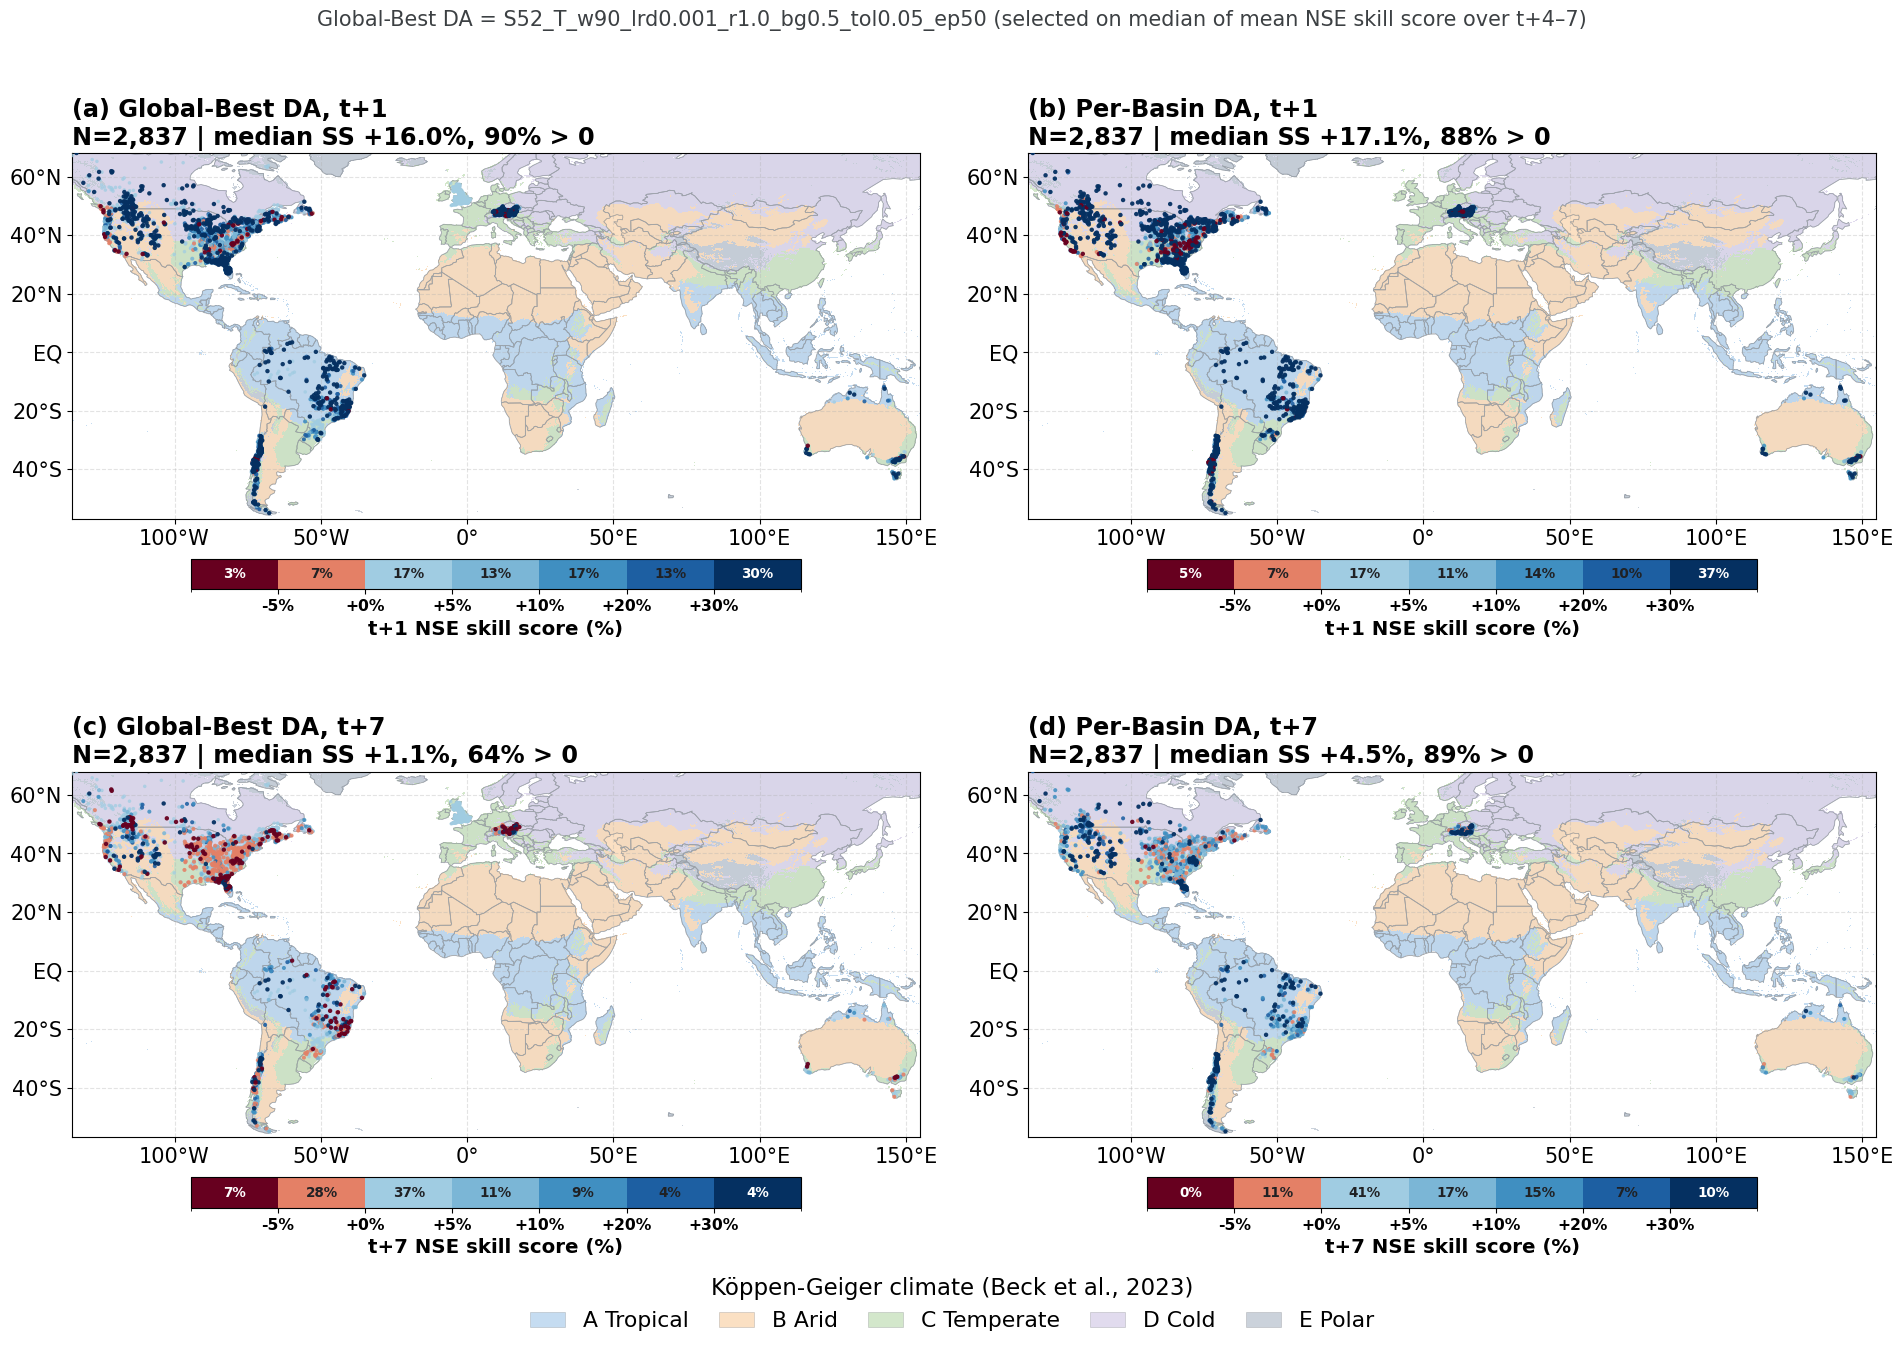

In [24]:
# Paper figure: 2x2 map (columns = Global-Best DA | Per-Basin DA; rows = grid_leads).
# Global-Best / Per-Basin DA follow the notebook-wide SELECTION (same config in both rows).
# Same view is available in the dashboard above via View mode = "Paper 2×2" (or view_mode="map_grid").
fig_map = session.plot_catchment_map(
    color_by="skill_nse",
    config_mode="grid",
    grid_leads=(1, 7),
    # Colour scale — pick one:
    #   fixed 7 bins (edges in SS units; '0' keeps the gain/loss boundary explicit):
    color_mode="binned", bin_thresholds="-0.05, 0, 0.05, 0.10, 0.20, 0.30",
    #   equal-count bins at the data quantiles (each colour = same share of basins):
    # color_mode="quantile", n_bins=7,
    #   continuous, range from the 5th–95th percentile instead of a fixed ±20%:
    # color_mode="continuous", vmin="auto", vmax="auto",
    marker_size=9, edge_width=0,     # smaller dots, no outline -> colours separate in dense clusters
    koppen="groups",          # "classes" for the full 30-class legend
    koppen_alpha=0.4,
    region="global",          # zoomed regions recompute N / stats for basins in view
    font_scale=1.5,
)
# fig_map.savefig("fig_da_map_2x2.png", dpi=300, bbox_inches="tight")


In [ ]:
# Skill by Köppen-Geiger climate group (Beck et al. 2023, Sci. Data 10:724; majority class over each Caravan polygon, 1-km grid)
# Toggles: leads, groups/classes, metric, stats, models (+ any sweep config),
# min basins per climate, same-basin comparison. Latest table is kept on session.koppen_table (e.g. .to_latex()).
# Static version: drop interactive=True (same arguments). session.get_basin_koppen() returns the per-basin classes.
session.koppen_skill_table(lead_times=(1, 7), by="group", interactive=True)

Output()

## Extended Paper Diagnostics: Statistical Significance, KGE Decomposition, Overfitting, Persistence/Autocorrelation, Flood Peaks & Multi-Year Cross-Validation

All 6 suites below default to **per-leadtime calculations with Leadtimes (`t+1`, `t+2`, `t+3`, `t+4`, `t+5`, `t+6`, `t+7`) as Columns**, and include interactive `ipywidgets` controls (`interactive=True`, `lead_time=1`, `show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"]`, `catchment_filter="all"`) matching `session.plot_ecdfs(...)`:
1. **Paired Wilcoxon Signed-Rank Significance (`show_wilcoxon_significance_table`)**: Two-sided paired Wilcoxon $p$-values (with Holm–Bonferroni correction across the 7 lead times) and basin win/harm rates vs. Open-Loop Baseline and vs. Post-Processing PP, with `t+1..t+7` as columns.
2. **KGE & NSE Component Decomposition (`show_kge_decomposition_suite`)**: Reports **both raw median $M$** (direction of dispersion $\alpha = \sigma_{\text{sim}}/\sigma_{\text{obs}}$ and volume bias $\beta_{\text{KGE}} = \mu_{\text{sim}}/\mu_{\text{obs}}$, $\beta_{\text{NSE}}$) and **distance-to-optimum Skill Score $\text{SS}_M$ (%)** across `t+1..t+7` columns, with interactive component, model, catchment, and leadtime toggles.
3. **Assimilation Overfitting vs. Forecast Generalization (`show_assimilation_overfitting_suite`)**: Compares in-window optimization fit (`t+0 (In-Win)`) against out-of-sample forecast skill across `t+1..t+7` columns, with an interactive Lead Time slider (`t+L`) and catchment filter.
4. **Persistence & Model Streamflow / Residual Autocorrelation (`show_persistence_autocorrelation_suite`)**:
   - **Table 1 (`df_pers_leads`)**: Per-leadtime (`t+1..t+7` columns) comparison of **Observed**, **Open-Loop Baseline**, **DA models (`Global-Best DA`, `Per-Basin DA`)**, and **Post-Processing models (`Global-Best PP`, `Per-Basin PP`)** across:
     1. Lag-$L$ Streamflow Autocorrelation $\rho_Q(L) = \text{Corr}(\hat{Q}(t+L, L), \hat{Q}(t, L))$
     2. Issue-Date Flow Persistence $\text{Corr}(\hat{Q}(t+L \mid t), Q_{\text{obs}}(t))$
     3. Residual Error Autocorrelation $\rho_e(L) = \text{Corr}(e(t+L, L), e(t, L))$ vs. **Assumed PP Decay $\rho^L$**
     4. Forecast Performance ($\text{NSE}_{\text{pers}}$, $\text{NSE}_{\text{base}}$, and $\text{SS}_{\text{NSE}}$)
   - **Table 2 (`df_pers_strata`) & 2x2 Interactive Plot**: Stratified by Lag-1 Open-Loop Residual Autocorrelation Quartiles $\rho_e(1)$ (`Q1: Low Memory (Flashy)` .. `Q4: High Memory (Baseflow)`), showing **both model autocorrelation and $\text{SS}_{\text{NSE}}$** with interactive toggles to filter by **Catchment Type** (Arid vs. Humid, Köppen A–E, Flashy vs. Baseflow, Snow-Dominant, Base NSE tiers) and a **Lead Time Slider (`t+1..t+7`)**.
5. **High-Flow Exceedance ($Q_{90}/Q_{95}$) & Flood Peak Timing/Magnitude (`show_event_peak_and_exceedance_suite`)**: Categorical Precision, Recall (POD), CSI, F1, and Zero-Alarm rate at $Q_{90}$ and $Q_{95}$, plus flood event Peak Timing Error (local $\pm 2\text{d}$ and extended $[-2,+7]\text{d}$ phase-lag windows), Peak Flow Error ($\text{PFE}$), and Top-2% Volume Bias ($\text{FHV}$) across `t+1..t+7` columns.
6. **Multi-Year Leave-One-Year-Out Cross-Validation (`show_temporal_cv_suite`)**: 6-fold Leave-One-Year-Out CV (`5-Year Train -> 1-Year Out-of-Sample Test` across `2017..2022`) and calibration training-length ladder ($K = 1\dots 5$ training years) with `t+1..t+7` as columns.

In [ ]:
# 1. Paired Two-Sided Wilcoxon Signed-Rank Significance & Win-Rate Table (Leadtimes t+1..t+7 as Columns)
# Interactive toggles for Metric, Columns (Per-Leadtime vs. Grouped), Catchment Regime, and Models:
df_wilcoxon = session.show_wilcoxon_significance_table(
    metric="skill_nse",
    lead_time=1,
    interactive=True,
    show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"],
)s

[EXTENDED METRICS] Computing yearly CV, model autocorrelation, and peak/exceedance caches across 4 shards x (Observed + Baseline + 32 DA + 7 PP configs)...


/usr/local/google/home/kruparell/miniforge3/envs/googlehydrology/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/usr/local/google/home/kruparell/miniforge3/envs/googlehydrology/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/usr/local/google/home/kruparell/miniforge3/envs/googlehydrology/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/usr/local/google/home/kruparell/miniforge3/envs/googlehydrology/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Output()

In [ ]:
# 2. KGE & NSE Component Decomposition (Pearson-r, Alpha-NSE, Beta-KGE, Beta-NSE: Raw Median & Skill Score % Across t+1..t+7 Columns)
df_kge_decomp = session.show_kge_decomposition_suite(
    lead_time=1,
    interactive=True,
    show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"],
    stat="median",
)

Output()

In [ ]:
# 3. Assimilation Overfitting vs. Out-of-Sample Forecast Generalization (In-Window t+0 vs. Per-Leadtime Columns t+1..t+7)
# Use the Lead Time slider (t+1..t+7) and Catchment filter dropdown to inspect generalization retention across regimes:
df_overfit = session.show_assimilation_overfitting_suite(
    lead_time=1,
    interactive=True,
    catchment_filter="all",
)

Output()

In [ ]:
# 4. Persistence & Model Streamflow / Residual Autocorrelation Suite (Observed, Baseline, DA & Post-Processing PP)
# Explore why methods succeed or fail across lead times and catchment regimes:
#   - Autocorr View dropdown: switch between Streamflow Autocorr ρ_Q(L), Issue-Date Flow Persistence Corr(Q̂(t+L|t), Q_obs(t)),
#     and Residual Error Autocorr ρ_e(L) vs. Assumed PP Decay ρ^L
#   - Catchment Type dropdown: filter by Arid / Semi-Arid, Humid, Köppen A–E, Flashy vs. Baseflow, Snow-Dominant, or Base NSE tiers
#   - Lead Time slider (t+1..t+7): inspect ECDF and ρ_e(1) quartile bar charts at any lead time t+L
df_pers_leads, df_pers_strata = session.show_persistence_autocorrelation_suite(
    lead_time=1,
    interactive=True,
    show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"],
    catchment_filter="all",
    autocorr_type="flow_lagL",
)

Output()

In [ ]:
# 5 & 6. High-Flow Exceedance (Precision, Recall/POD, CSI, F1 at Q90 & Q95) and Flood Peak Timing (PTE) & Magnitude (PFE, FHV)
# Leadtimes (t+1..t+7) are formatted as columns; toggle Threshold (Q90/Q95), Lead Time (t+L), Catchment Type, and Models:
df_exceedance, df_peak_timing = session.show_event_peak_and_exceedance_suite(
    lead_time=1,
    interactive=True,
    show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"],
    catchment_filter="all",
)

[SELECTION] Global-Best 'S52_T_w90_lrd0.001_r1.0_bg0.5_tol0.05_ep50' is not among the configs passed here; falling back to a local pick.


KeyError: 'Column not found: NSE Delta'

In [ ]:
# 7. Multi-Year Leave-One-Year-Out Cross-Validation (5-Year Train -> 1-Year Out-of-Sample Test across 2017..2022)
# Leadtimes (t+1..t+7) are formatted as columns across the Summary, Calibration-Length Ladder (K=1..5 yrs), and Fold tables:
cv_results = session.show_temporal_cv_suite(
    cv_years=(2017, 2018, 2019, 2020, 2021, 2022),
    lead_time=1,
    interactive=True,
    show=["global_da", "per_basin_da", "global_rho", "per_basin_rho"],
    catchment_filter="all",
)

Output()